# COMPASS-SVP: Verbal-Visual (VV) Dimension Benchmark, Prototype Optimization, and t-SNE Visualization

## 1. Elbow Method Optimization for Optimal Prototype Number (K) Selection (Verbal-Visual Dimension)

Extracting WCSS values for VV dimension across LOSO iterations...


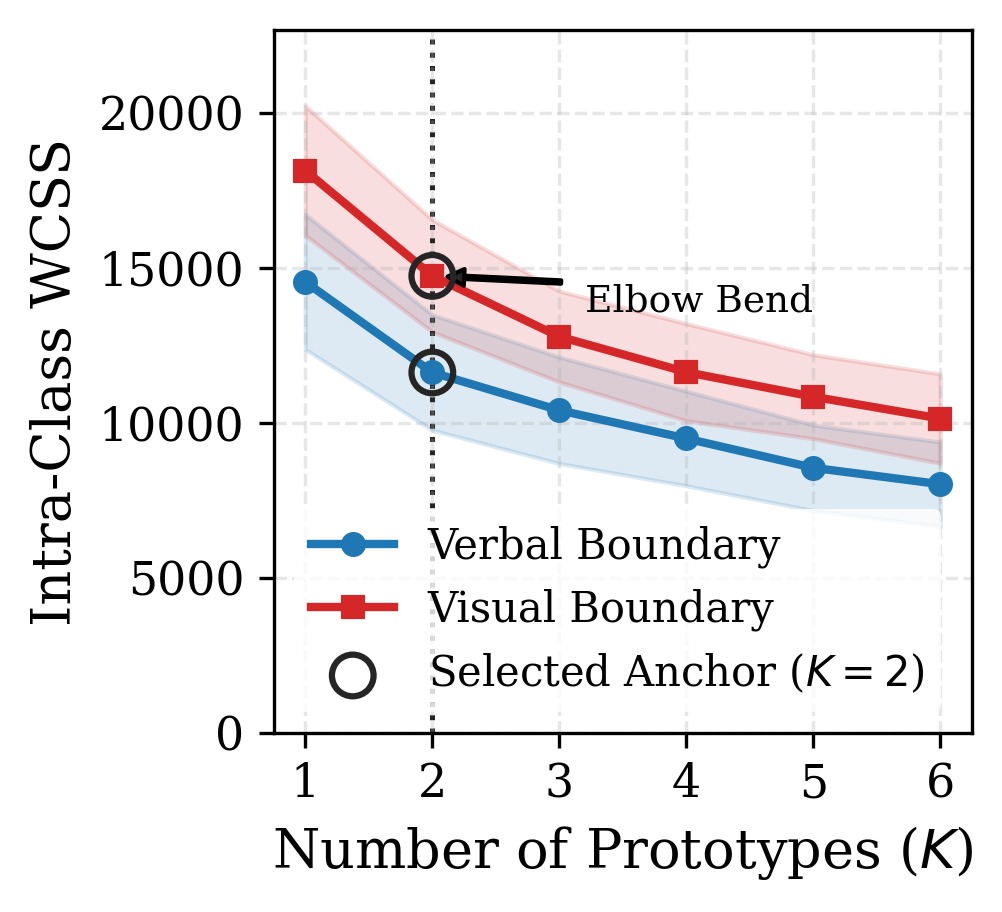

[SUCCESS] Publication-ready plot exported to: fig6_wcss_convergence_vv.png


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PLOT STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 13
})

file_input = "combined_fe_plv_vv.csv"
FIXED_SEED = 42
max_k = 6

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    df["y"] = df["label"].map({"verbal": 0, "visual": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))
    
    wcss_matrix_c0 = []
    wcss_matrix_c1 = []
    
    print("Extracting WCSS values for VV dimension across LOSO iterations...")
    
    for test_subj in subjects:
        df_train = df[df["subject"] != int(test_subj)].copy()
        
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
        X_train = df_train[feature_cols].values
        y_train = df_train["y"].values
        
        svm_filter = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
        svm_filter.fit(X_train, y_train)
        
        sv_features = svm_filter.support_vectors_
        sv_labels = y_train[svm_filter.support_]
        
        fold_wcss_c0 = []
        fold_wcss_c1 = []
        
        for k in range(1, max_k + 1):
            X_sv_c0 = sv_features[sv_labels == 0]
            kmeans_c0 = KMeans(n_clusters=k, n_init='auto', random_state=FIXED_SEED)
            kmeans_c0.fit(X_sv_c0)
            fold_wcss_c0.append(kmeans_c0.inertia_)
            
            X_sv_c1 = sv_features[sv_labels == 1]
            kmeans_c1 = KMeans(n_clusters=k, n_init='auto', random_state=FIXED_SEED)
            kmeans_c1.fit(X_sv_c1)
            fold_wcss_c1.append(kmeans_c1.inertia_)
            
        wcss_matrix_c0.append(fold_wcss_c0)
        wcss_matrix_c1.append(fold_wcss_c1)
        
    avg_wcss_c0 = np.mean(wcss_matrix_c0, axis=0)
    std_wcss_c0 = np.std(wcss_matrix_c0, axis=0)
    
    avg_wcss_c1 = np.mean(wcss_matrix_c1, axis=0)
    std_wcss_c1 = np.std(wcss_matrix_c1, axis=0)
    
    k_values = np.arange(1, max_k + 1)
    
    # ==========================================
    # 2. WCSS CONVERGENCE PLOTTING & EXPORT
    # ==========================================
    fig, ax = plt.subplots(figsize=(3.5, 3.2), dpi=300)
    
    ax.plot(k_values, avg_wcss_c0, marker='o', markersize=5, linewidth=2.0, color='#1f77b4', label='Verbal Boundary')
    ax.fill_between(k_values, avg_wcss_c0 - std_wcss_c0, avg_wcss_c0 + std_wcss_c0, color='#1f77b4', alpha=0.15)
    
    ax.plot(k_values, avg_wcss_c1, marker='s', markersize=5, linewidth=2.0, color='#d62728', label='Visual Boundary')
    ax.fill_between(k_values, avg_wcss_c1 - std_wcss_c1, avg_wcss_c1 + std_wcss_c1, color='#d62728', alpha=0.15)
    
    ax.axvline(x=2, color='#252525', linestyle=':', linewidth=1.2, zorder=1)
    ax.scatter([2, 2], [avg_wcss_c0[1], avg_wcss_c1[1]], color='none', edgecolors='#252525', 
               s=100, linewidths=1.5, zorder=6, label='Selected Anchor ($K=2$)')
    
    ax.annotate('Elbow Bend', xy=(2, max(avg_wcss_c0[1], avg_wcss_c1[1])), 
                xytext=(3.2, max(avg_wcss_c0[0], avg_wcss_c1[0])*0.75),
                arrowprops=dict(facecolor='#252525', shrink=0.1, width=0.8, headwidth=4, headlength=4),
                fontsize=9, fontfamily='serif')
    
    ax.set_xlabel("Number of Prototypes ($K$)")
    ax.set_ylabel("Intra-Class WCSS")
    ax.set_xticks(k_values)
    ax.set_ylim(bottom=0, top=max(avg_wcss_c0[0], avg_wcss_c1[0]) * 1.25)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', framealpha=0.8)
    
    plt.tight_layout()
    output_name = "fig6_wcss_convergence_vv.png"
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Publication-ready plot exported to: {output_name}")

## 2. Hierarchical Classification Evaluation and Benchmark Summary (Verbal-Visual Dimension)

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_vv.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2  

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    df["y"] = df["label"].map({"verbal": 0, "visual": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())

    classifiers_pool = {
        "COMPASS-SVM (Euclidean)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "COMPASS-SVM (Cosine)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        
        "SVM (Baseline)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "Random Forest (Baseline)": RandomForestClassifier(n_estimators=100, random_state=FIXED_SEED),
        "MLP (Baseline)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=FIXED_SEED),
        "KNN (Baseline)": KNeighborsClassifier(n_neighbors=5)
    }

    print(f"COMPASS Grand Benchmark Full Metrics | K={K_PROTOTYPES_PER_CLASS} | Multi-Metric Geometry Evaluation")
    print(f"Evaluation: Strict Cross-Subject LOSO | Total Feature Dimensions: {len(feature_cols)}")
    print("=" * 115)

    global_summary = {}

    # ==========================================
    # 2. CLASSIFICATION & EVALUATION LOOP
    # ==========================================
    for model_name, extractor in classifiers_pool.items():
        header_title = f" EVALUATION & DETAILED REPORT: {model_name} (Verbal-Visual Dimension) "
        print("\n" + "#" * 115)
        print(header_title)
        print("#" * 115)
        
        is_compass = model_name.startswith("COMPASS-")
        is_cosine = "Cosine" in model_name
        
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []

        # ==========================================
        # 3. STRICT LOSO LOOP 
        # ==========================================
        for test_subj in subjects:
            set_seed(FIXED_SEED)
            df_train = df[df["subject"] != test_subj].copy()
            df_test  = df[df["subject"] == test_subj].copy()
            
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

            X_train, y_train = df_train[feature_cols].values, df_train["y"].values
            X_test, y_test   = df_test[feature_cols].values, df_test["y"].values
            
            extractor.fit(X_train, y_train)
            
            if is_compass:
                if hasattr(extractor, "support_vectors_"):
                    sv_features = extractor.support_vectors_
                    sv_labels = y_train[extractor.support_]
                elif hasattr(extractor, "predict_proba"):
                    probs = extractor.predict_proba(X_train)
                    margins = np.abs(probs[:, 1] - probs[:, 0])
                    threshold = np.median(margins)
                    idx = margins >= threshold
                    sv_features = X_train[idx]
                    sv_labels = y_train[idx]
                else:
                    sv_features = X_train
                    sv_labels = y_train
                
                prototypes = []
                proto_labels = []
                
                for label_val in [0, 1]:
                    X_sv_class = sv_features[sv_labels == label_val]
                    current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
                    
                    set_seed(FIXED_SEED)
                    kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
                    kmeans.fit(X_sv_class)
                    
                    prototypes.append(kmeans.cluster_centers_)
                    proto_labels.append(np.full(current_k, label_val))
                    
                all_prototypes = np.vstack(prototypes)
                all_proto_labels = np.concatenate(proto_labels)
                
                dist_metric = 'cosine' if is_cosine else 'euclidean'
                distances = cdist(X_test, all_prototypes, metric=dist_metric)
                y_test_pred = all_proto_labels[np.argmin(distances, axis=1)]
            else:
                y_test_pred = extractor.predict(X_test)
            
            df_test["y_pred"] = y_test_pred
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            # --- WINDOW TO TRIAL MAJORITY VOTING ---
            subj_trial_true, subj_trial_pred = [], []
            
            sorted_trials = sorted(df_test["trial"].unique())
            
            for trial_id in sorted_trials:
                g = df_test[df_test["trial"] == trial_id]
                t_true = "verbal" if g["y"].iloc[0] == 0 else "visual"
                
                verbal_votes = int((g["y_pred"] == 0).sum())
                visual_votes = int((g["y_pred"] == 1).sum())
                
                pred_trial_idx = 0 if verbal_votes >= visual_votes else 1
                pred_trial_str = "verbal" if pred_trial_idx == 0 else "visual"
                
                all_trial_pred.append(pred_trial_idx)
                all_trial_true.append(g["y"].iloc[0])
                
                subj_trial_pred.append(pred_trial_idx)
                subj_trial_true.append(g["y"].iloc[0])
                
                status_trial = "correct" if pred_trial_str == t_true else "incorrect"
                
                trial_records.append({
                    "subject": test_subj,
                    "trial": trial_id,
                    "True_Class": t_true,
                    "Majority": pred_trial_str,
                    "verbal_Votes": verbal_votes,
                    "visual_Votes": visual_votes,
                    "Status": status_trial
                })

            # --- TRIAL TO SUBJECT MAJORITY VOTING ---
            s_true = "verbal" if df_test["y"].iloc[0] == 0 else "visual"
            
            verbal_trials_count = int(sum(1 for p in subj_trial_pred if p == 0))
            visual_trials_count = int(sum(1 for p in subj_trial_pred if p == 1))
            
            # Updated subject-level majority voting rule requested
            subj_pred_idx = 0 if verbal_trials_count > visual_trials_count else 1
            subj_pred_str = "verbal" if subj_pred_idx == 0 else "visual"
            
            all_subj_true.append(df_test["y"].iloc[0])
            all_subj_pred.append(subj_pred_idx)
            
            status_subj = "correct" if subj_pred_str == s_true else "incorrect"
            
            subject_records.append({
                "subject": test_subj,
                "True_Class": s_true,
                "Majority": subj_pred_str,
                "verbal_Trials": verbal_trials_count,
                "visual_Trials": visual_trials_count,
                "Status": status_subj
            })

            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            print(f"Subject {test_subj} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

        # ==========================================
        # 4. PRINT DETAILED REPORTS (IN ENGLISH)
        # ==========================================
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
        win_acc = accuracy_score(all_win_true, all_win_pred)
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=["verbal", "visual"], digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        
        t_acc = accuracy_score(all_trial_true, all_trial_pred)
        t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        
        print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
        print(f"Trial-Level Precision : {t_prec:.4f}")
        print(f"Trial-Level Recall    : {t_rec:.4f}")
        print(f"Trial-Level F1-Score  : {t_f1:.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        s_acc = accuracy_score(all_subj_true, all_subj_pred)
        s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
        print("-" * 65)
        print(f"Accuracy  : {s_acc*100:.2f}%")
        print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
        print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
        print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               Verbal  Visual")
        print(f"Verbal      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"Visual      :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

        global_summary[model_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(t_acc * 100, 2),
            "Subj Acc (%)": round(s_acc * 100, 2),
            "Subj Prec (%)": round(s_prec * 100, 2),
            "Subj Rec (%)": round(s_rec * 100, 2),
            "Subj F1 (%)": round(s_f1 * 100, 2)
        }
        print(f"\n[COMPLETED] {model_name} -> Final Subject Accuracy: {s_acc*100:.2f}%")
        print("-" * 80)

    # ==========================================
    # 5. FINAL SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(" FINAL BENCHMARK SUMMARY: PURE BASELINES VS COMPASS-ENHANCED (DIMENSION: VV) ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)

COMPASS Grand Benchmark Full Metrics | K=2 | Multi-Metric Geometry Evaluation
Evaluation: Strict Cross-Subject LOSO | Total Feature Dimensions: 28

###################################################################################################################
 EVALUATION & DETAILED REPORT: COMPASS-SVM (Euclidean) (Verbal-Visual Dimension) 
###################################################################################################################
Subject 1 | Win Acc: 36.67% | Trial Acc: 35.00% | Status: INCORRECT
Subject 2 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 3 | Win Acc: 66.67% | Trial Acc: 85.00% | Status: CORRECT
Subject 4 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 5 | Win Acc: 56.67% | Trial Acc: 70.00% | Status: CORRECT
Subject 6 | Win Acc: 64.00% | Trial Acc: 75.00% | Status: CORRECT
Subject 7 | Win Acc: 57.33% | Trial Acc: 70.00% | Status: CORRECT
Subject 8 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Su

## 3. t-SNE Latent Space Manifold Projection and Geometric Decision Boundary Visualization

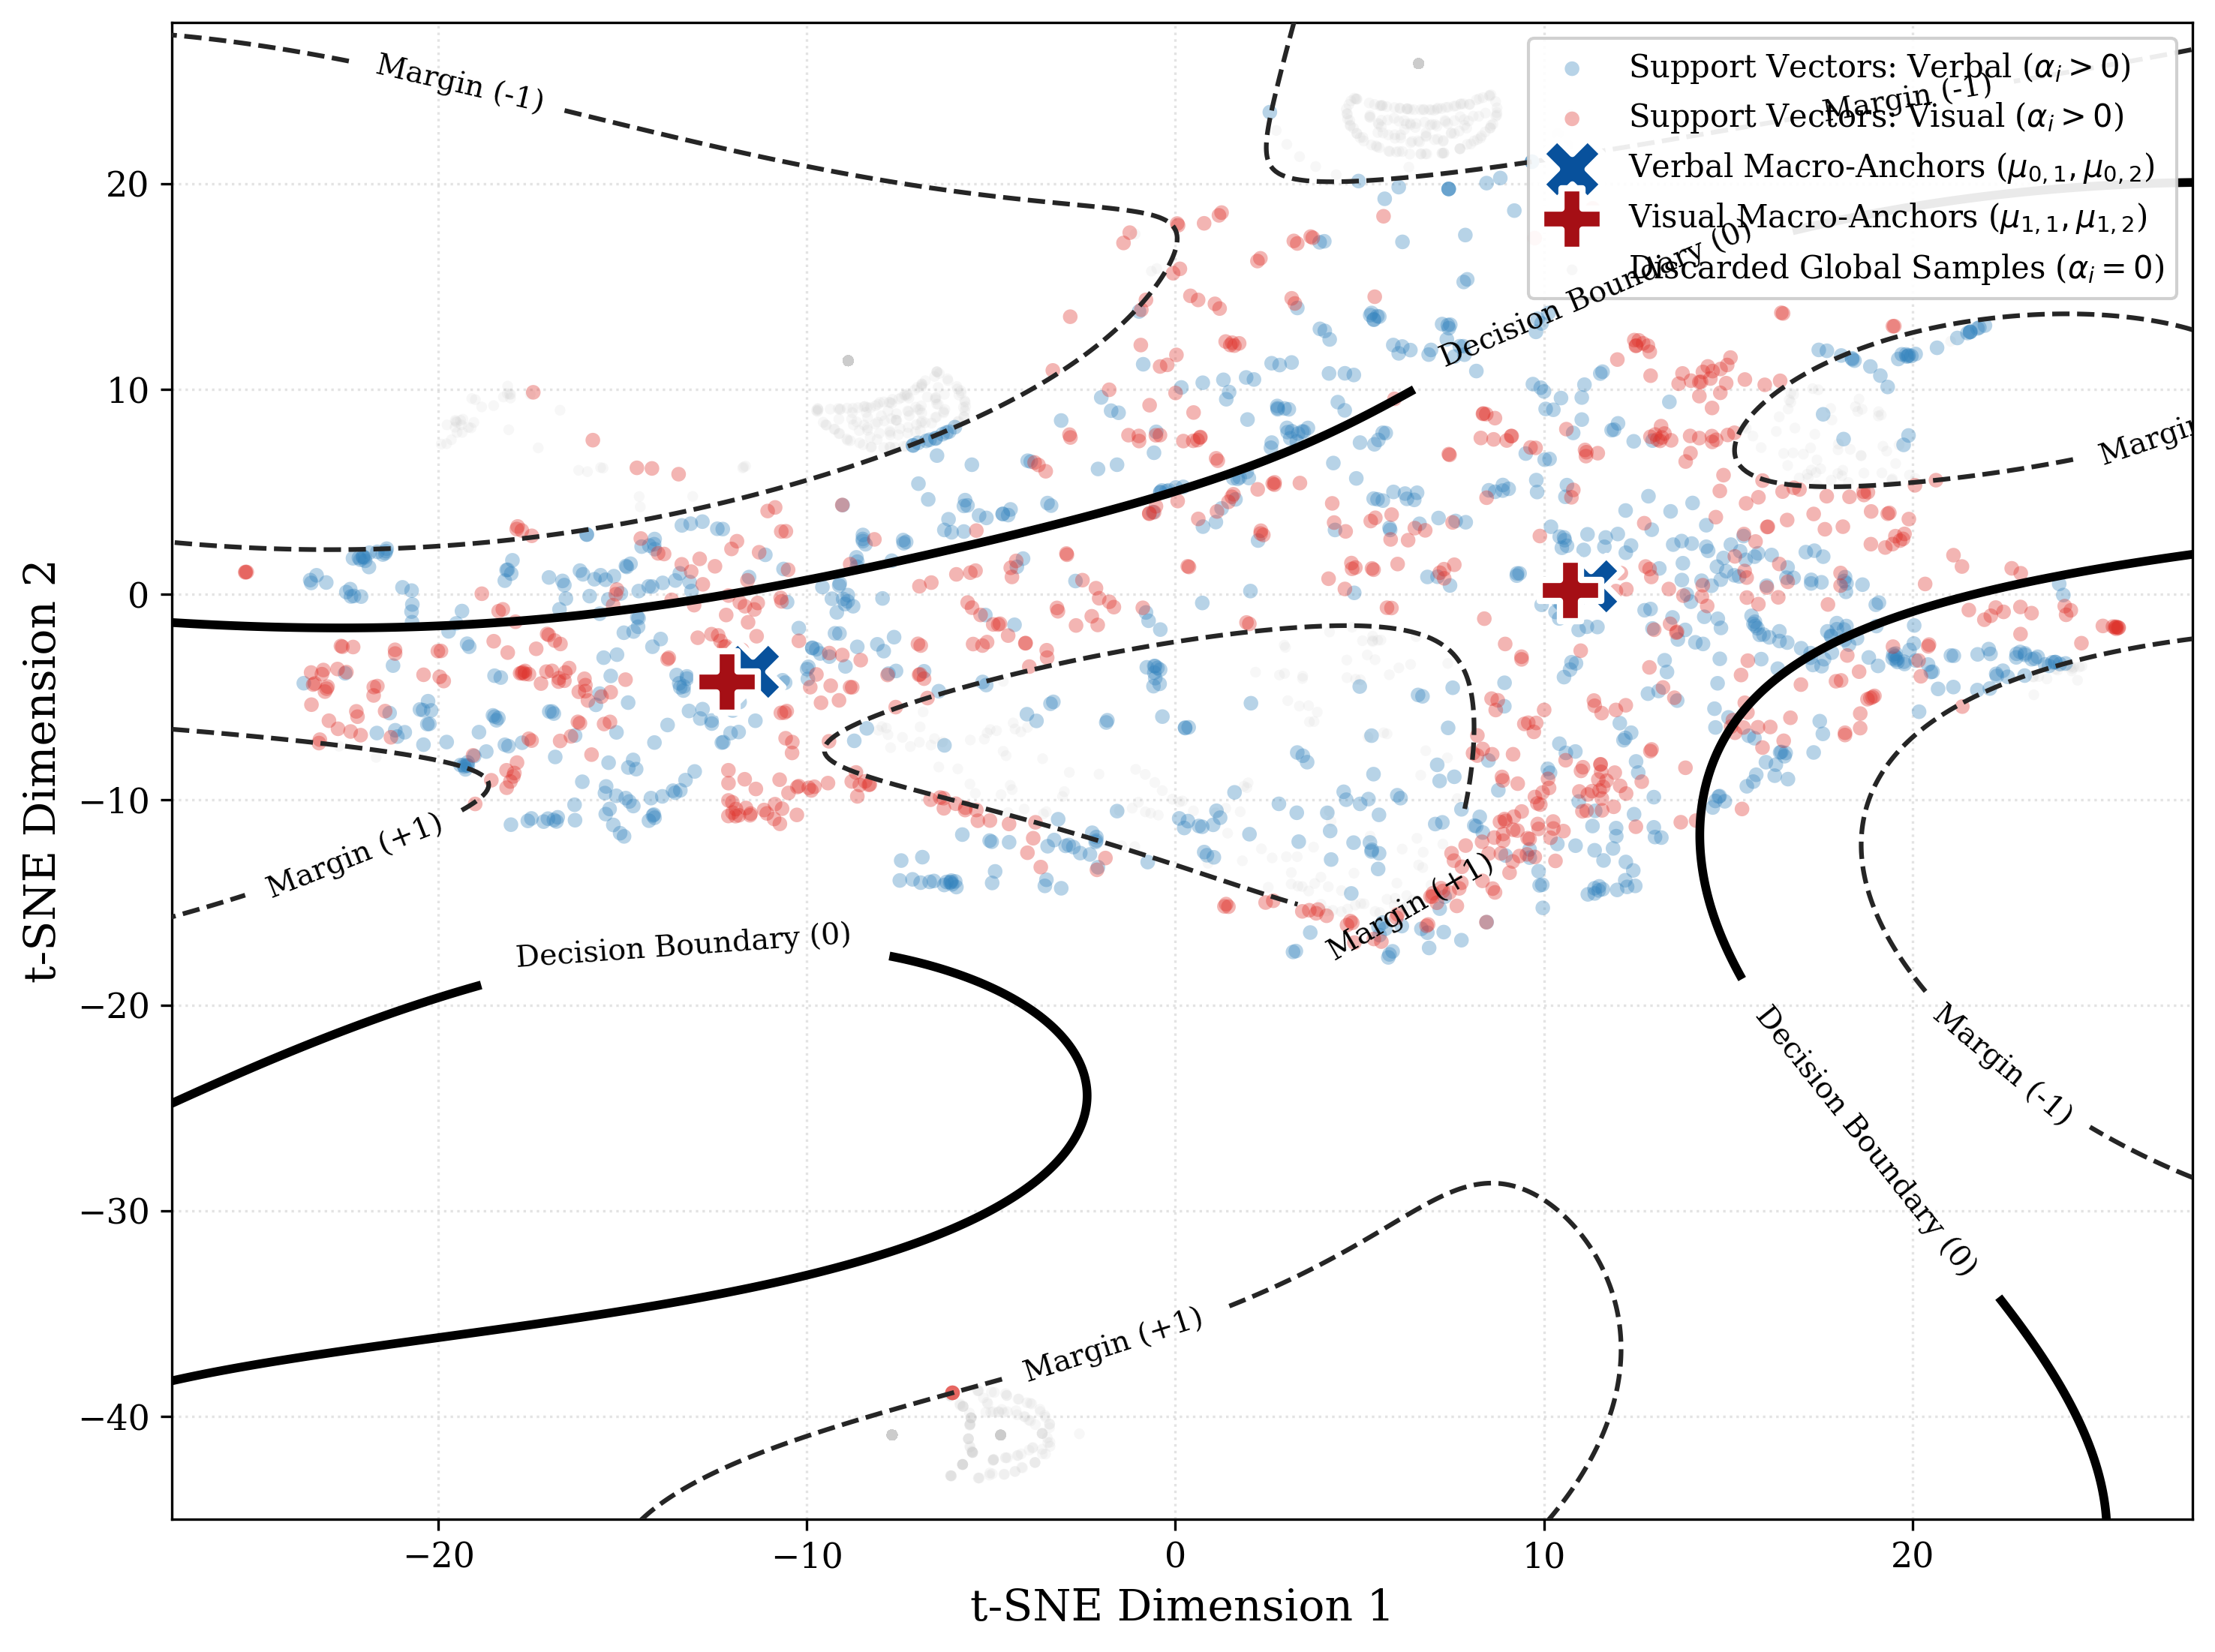

[SUCCESS] t-SNE-based VV decision boundary plot successfully


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Q1 JOURNAL-GRADE PLOT STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 14
})

file_input = "combined_fe_plv_vv.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2 

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    # Load real Verbal-Visual dataset
    df = pd.read_csv(file_input)
    df["y"] = df["label"].map({"verbal": 0, "visual": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))
    
    # Take the last subject as the test set for LOSO round simulation
    visualize_test_subj = subjects[-1]
    df_train = df[df["subject"] != visualize_test_subj].copy()
    
    # Subject-wise step-by-step standardization
    for s in df_train["subject"].unique():
        mask = df_train["subject"] == s
        scaler_tr = StandardScaler()
        df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
    X_train = df_train[feature_cols].values
    y_train = df_train["y"].values
    
    # ==========================================
    # t-SNE OPTIMIZATION: PERPLEXITY SET TO 50
    # ==========================================
    tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto', 
                init='pca', random_state=FIXED_SEED)
    X_tsne_train = tsne.fit_transform(X_train)
    
    # ==========================================
    # 2. SVM MODELING APPLYING NATIVE C = 1.0
    # ==========================================
    extractor = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
    extractor.fit(X_tsne_train, y_train)
    
    sv_features = extractor.support_vectors_
    sv_labels = y_train[extractor.support_]
    
    all_indices = np.arange(len(X_tsne_train))
    discarded_indices = np.setdiff1d(all_indices, extractor.support_)
    X_tsne_discarded = X_tsne_train[discarded_indices]
    y_tsne_discarded = y_train[discarded_indices]
    
    # Boundary Contour Macro-Prototype Extraction (K-Means Condensation)
    prototypes = []
    for label_val in [0, 1]:
        X_sv_class = sv_features[sv_labels == label_val]
        current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
        kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
        kmeans.fit(X_sv_class)
        prototypes.append(kmeans.cluster_centers_)
        
    X_tsne_proto = np.vstack(prototypes)
    
    # ==========================================
    # 3. NON-LINEAR HYPERPLANE MESHGRID GENERATION ON MANIFOLD
    # ==========================================
    ax_min_x, ax_max_x = X_tsne_train[:, 0].min() - 3, X_tsne_train[:, 0].max() + 3
    ax_min_y, ax_max_y = X_tsne_train[:, 1].min() - 3, X_tsne_train[:, 1].max() + 3
    xx, yy = np.meshgrid(np.linspace(ax_min_x, ax_max_x, 600),
                         np.linspace(ax_min_y, ax_max_y, 600))
    
    Z = extractor.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # ==========================================
    # 4. PLOTTING WITH STRICT VISUAL HIERARCHY (FIGURE 3: VV)
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 7.5), dpi=300)
    
    # Layer 1: Discarded Samples (Bottom layer & very faded)
    ax.scatter(X_tsne_discarded[:, 0], X_tsne_discarded[:, 1], c='#cccccc', 
               s=12, alpha=0.15, edgecolors='none', 
               label='Discarded Global Samples ($\\alpha_i = 0$)', zorder=1)
    
    # Layer 2: Support Vectors (Alpha=0.35 & s=22 so boundaries still pierce visually)
    mask_c0 = sv_labels == 0
    mask_c1 = sv_labels == 1
    ax.scatter(sv_features[mask_c0, 0], sv_features[mask_c0, 1], c='#3182bd', s=22,
               alpha=0.35, edgecolors='none', label='Support Vectors: Verbal ($\\alpha_i > 0$)', zorder=2)
    ax.scatter(sv_features[mask_c1, 0], sv_features[mask_c1, 1], c='#de2d26', s=22,
               alpha=0.35, edgecolors='none', label='Support Vectors: Visual ($\\alpha_i > 0$)', zorder=2)
    
    # Layer 3: Decision Boundary & Margins (Thickened & High Z-order)
    contour = ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['#252525', '#000000', '#252525'],
                         linestyles=['--', '-', '--'], linewidths=[1.5, 2.8, 1.5], zorder=4)
    ax.clabel(contour, inline=True, fmt={-1: 'Margin (-1)', 0: 'Decision Boundary (0)', 1: 'Margin (+1)'}, 
              fontsize=9.5, colors='#000000')
    
    # Layer 4: Macro-Anchors / Prototypes (Top layer, contrasting & clear)
    ax.scatter(X_tsne_proto[:2, 0], X_tsne_proto[:2, 1], c='#08519c', marker='X', s=380, 
               edgecolors='white', linewidth=2.0, zorder=10, label='Verbal Macro-Anchors ($\\mu_{0,1}, \\mu_{0,2}$)')
    ax.scatter(X_tsne_proto[2:, 0], X_tsne_proto[2:, 1], c='#a50f15', marker='P', s=380, 
               edgecolors='white', linewidth=2.0, zorder=10, label='Visual Macro-Anchors ($\\mu_{1,1}, \\mu_{1,2}$)')
    
    # Visual Aesthetic Parameters
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.set_xlim(ax_min_x + 1, ax_max_x - 1)
    ax.set_ylim(ax_min_y + 1, ax_max_y - 1)
    ax.grid(True, linestyle=':', alpha=0.35)
    
    # Legend Placement
    handles, labels = ax.get_legend_handles_labels()
    legend_order = [1, 2, 3, 4, 0]
    ax.legend([handles[idx] for idx in legend_order], [labels[idx] for idx in legend_order], 
              loc='upper right', frameon=True, facecolor='white', framealpha=0.92, edgecolor='#cccccc')
    
    plt.tight_layout()
    #output_img_name = "fig3_real_decision_boundary_vv_tsne_c1.png"
    #plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] t-SNE-based VV decision boundary plot successfully")

## 4. Component-Wise Ablation Study for COMPASS-SVP Framework Validation (Active-Reflective Dimension)

In [4]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. PERSIAPAN DATA (VERBAL-VISUAL)
# ==========================================
file_input = "combined_fe_plv_vv.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2  

if not os.path.exists(file_input):
    print(f"File {file_input} tidak ditemukan!")
else:
    df = pd.read_csv(file_input)
    # --- PEMETAAN LABEL VERBAL-VISUAL ---
    df["y"] = df["label"].map({"verbal": 0, "visual": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())
    
    classifiers_pool = {
        "COMPASS-SVP (Full System)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "COMPASS-SVP (Skenario A: Tanpa K-Means)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "COMPASS-SVP (Skenario B: Tanpa Sifting SVM)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "SVM (Baseline)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
    }

    print(f"Ablasi Studi Komponen COMPASS-SVP | K={K_PROTOTYPES_PER_CLASS} | Metrik Geometri: EUCLIDEAN")
    print(f"Evaluasi: Strict LOSO Lintas Subjek | Total Dimensi Fitur: {len(feature_cols)}")
    print("=" * 115)

    global_summary = {}

    # ==========================================
    # 2. LOOP ALGORITMA KLASIFIKASI
    # ==========================================
    for model_name, extractor in classifiers_pool.items():
        print(f"\n>>> Melatih & Menguji Model: {model_name} ...")
        print("-" * 80)
        
        is_compass_full = model_name.startswith("COMPASS-SVP (Full")
        is_abl_a = "Skenario A" in model_name  # Tanpa K-Means (Pakai semua SV mentah)
        is_abl_b = "Skenario B" in model_name  # Tanpa Sifting SVM (K-Means langsung dari semua X_train)
        is_compass_any = is_compass_full or is_abl_a or is_abl_b
        
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []

        # ==========================================
        # 3. STRICT LOSO LOOP 
        # ==========================================
        for test_subj in subjects:
            set_seed(FIXED_SEED)
            df_train = df[df["subject"] != test_subj].copy()
            df_test  = df[df["subject"] == test_subj].copy()
            
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

            X_train, y_train = df_train[feature_cols].values, df_train["y"].values
            X_test, y_test   = df_test[feature_cols].values, df_test["y"].values
            
            extractor.fit(X_train, y_train)
            
            if is_compass_any:
                if is_abl_b:
                    # Skenario B: Lewati sifting SVM, langsung gunakan seluruh data latih
                    sv_features = X_train
                    sv_labels = y_train
                else:
                    # Full System & Skenario A: Mengambil Support Vectors dari SVM
                    if hasattr(extractor, "support_vectors_"):
                        sv_features = extractor.support_vectors_
                        sv_labels = y_train[extractor.support_]
                    else:
                        sv_features = X_train
                        sv_labels = y_train
                
                prototypes = []
                proto_labels = []
                
                for label_val in [0, 1]:
                    X_sv_class = sv_features[sv_labels == label_val]
                    
                    if is_abl_a:
                        # Skenario A: Tanpa K-Means, jadikan seluruh support vector sebagai prototipe
                        prototypes.append(X_sv_class)
                        proto_labels.append(np.full(len(X_sv_class), label_val))
                    else:
                        # Full System & Skenario B: Jalankan K-Means Clustering
                        current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
                        if current_k > 0:
                            set_seed(FIXED_SEED)
                            kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
                            kmeans.fit(X_sv_class)
                            prototypes.append(kmeans.cluster_centers_)
                            proto_labels.append(np.full(current_k, label_val))
                    
                all_prototypes = np.vstack(prototypes)
                all_proto_labels = np.concatenate(proto_labels)
                
                # --- PENGUKURAN JARAK EUCLIDEAN UNTUK DIMENSI VV ---
                distances = cdist(X_test, all_prototypes, metric='euclidean')
                y_test_pred = all_proto_labels[np.argmin(distances, axis=1)]
            else:
                y_test_pred = extractor.predict(X_test)
            
            df_test["y_pred"] = y_test_pred
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            v_trials = {0: 0, 1: 0}
            subj_trial_true, subj_trial_pred = [], []
            
            for trial_id, g in df_test.groupby("trial"):
                pred_trial = g["y_pred"].mode()[0]
                true_trial = g["y"].iloc[0]
                t_true_str = "verbal" if true_trial == 0 else "visual"
                pred_trial_str = "verbal" if pred_trial == 0 else "visual"
                
                verbal_votes = int((g["y_pred"] == 0).sum())
                visual_votes = int((g["y_pred"] == 1).sum())
                
                all_trial_pred.append(pred_trial)
                all_trial_true.append(true_trial)
                subj_trial_pred.append(pred_trial)
                subj_trial_true.append(true_trial)
                v_trials[pred_trial] += 1
                
                status_trial = "BENAR" if pred_trial_str == t_true_str else "SALAH"
                trial_records.append({
                    "subject": test_subj,
                    "trial": trial_id,
                    "True_Class": t_true_str,
                    "Majority": pred_trial_str,
                    "verbal_Votes": verbal_votes,
                    "visual_Votes": visual_votes,
                    "Status": status_trial
                })
                
            subj_pred_idx = 0 if v_trials[0] > v_trials[1] else 1
            subj_true_idx = df_test["y"].iloc[0]
            s_true_str = "verbal" if subj_true_idx == 0 else "visual"
            subj_pred_str = "verbal" if subj_pred_idx == 0 else "visual"
            
            all_subj_true.append(subj_true_idx)
            all_subj_pred.append(subj_pred_idx)
            
            is_correct = "BENAR" if subj_pred_idx == subj_true_idx else "SALAH"
            subject_records.append({
                "subject": test_subj,
                "True_Class": s_true_str,
                "Majority": subj_pred_str,
                "verbal_Trials": v_trials[0],
                "visual_Trials": v_trials[1],
                "Status": is_correct
            })
            
            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            
            print(f"Subjek {test_subj} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {is_correct}")

        win_acc = accuracy_score(all_win_true, all_win_pred)
        trial_acc = accuracy_score(all_trial_true, all_trial_pred)
        subj_acc = accuracy_score(all_subj_true, all_subj_pred)
        
        subj_precision = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        subj_recall = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        subj_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=["verbal", "visual"], digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        print(f"Trial-Level Accuracy  : {trial_acc*100:.2f}%")
        print(f"Trial-Level Precision : {precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0):.4f}")
        print(f"Trial-Level Recall    : {recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0):.4f}")
        print(f"Trial-Level F1-Score  : {f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0):.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
        print("-" * 65)
        print(f"Accuracy  : {subj_acc*100:.2f}%")
        print(f"Precision : {subj_precision*100:.2f}% ({subj_precision:.4f})")
        print(f"Recall    : {subj_recall*100:.2f}% ({subj_recall:.4f})")
        print(f"F1-Score  : {subj_f1*100:.2f}% ({subj_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               Verbal  Visual")
        print(f"Verbal      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"Visual      :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

        global_summary[model_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(trial_acc * 100, 2),
            "Subj Acc (%)": round(subj_acc * 100, 2),
            "Subj Prec (%)": round(subj_precision * 100, 2),
            "Subj Rec (%)": round(subj_recall * 100, 2),
            "Subj F1 (%)": round(subj_f1 * 100, 2)
        }
        print(f"\n[SELESAI] {model_name} -> Subject Acc Final: {subj_acc*100:.2f}%")
        print("-" * 80)

    print("\n" + "="*125)
    print(" TABEL HASIL STUDI ABLASI KOMPONEN COMPASS-SVP (DIMENSI: VERBAL-VISUAL) ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)

Ablasi Studi Komponen COMPASS-SVP | K=2 | Metrik Geometri: EUCLIDEAN
Evaluasi: Strict LOSO Lintas Subjek | Total Dimensi Fitur: 28

>>> Melatih & Menguji Model: COMPASS-SVP (Full System) ...
--------------------------------------------------------------------------------
Subjek 1 | Win Acc: 36.67% | Trial Acc: 35.00% | Status: SALAH
Subjek 2 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: BENAR
Subjek 3 | Win Acc: 66.67% | Trial Acc: 85.00% | Status: BENAR
Subjek 4 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: BENAR
Subjek 5 | Win Acc: 56.67% | Trial Acc: 70.00% | Status: BENAR
Subjek 6 | Win Acc: 64.00% | Trial Acc: 75.00% | Status: BENAR
Subjek 7 | Win Acc: 57.33% | Trial Acc: 70.00% | Status: BENAR
Subjek 8 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: BENAR
Subjek 9 | Win Acc: 47.00% | Trial Acc: 45.00% | Status: SALAH
Subjek 10 | Win Acc: 59.67% | Trial Acc: 60.00% | Status: BENAR

=================================== WINDOW-LEVEL PERFORMANCE (COMPASS-SVP (Full System)) =

## 5. State-of-the-Art Comparative Benchmark: Adapted LSTM-CNN Architecture (Jawed et al., 2024)

In [5]:
import pandas as pd
import numpy as np
import os
import random

# --- LOCAL GPU HANDLING (Preventing Deadlock/Freeze in VS Code) ---
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 
# -------------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ==========================================
# 1. SEED & DATA CONFIGURATION
# ==========================================
FIXED_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

file_input = "combined_fe_plv_vv.csv"  

# ==========================================
# 2. LSTM-CNN ARCHITECTURE DEFINITION (Adapted Jawed et al., 2024)
# ==========================================
def build_lstm_cnn_model(input_shape=(28, 1), num_classes=2):
    inputs = Input(shape=input_shape)
    
    # Layer 1: LSTM
    x = LSTM(64, return_sequences=True)(inputs) 
    
    # Layer 2: Conv1D (256 filters, kernel size 3)
    x = Conv1D(filters=256, kernel_size=3, padding='same', activation='relu')(x)
    
    # Layer 3: Dropout (20%)
    x = Dropout(0.20)(x)
    
    # Layer 4: MaxPooling1D (Pool size = 3)
    x = MaxPooling1D(pool_size=3, padding='same')(x)
    
    # Layer 5 & 6: Flatten & Dense (Softmax)
    x = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# ==========================================
# 3. MAIN WORKFLOW (LOSO + SCALING + VOTING)
# ==========================================
if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic dimension detection based on filename
    if "AR" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
        class_names = ["active", "reflective"]
    else:
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        class_names = ["verbal", "visual"]
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))

    all_win_true, all_win_pred = [], []
    trial_records = []
    subject_records = []
    all_trial_true, all_trial_pred = [], []
    all_subj_true, all_subj_pred = [], []

    model_name = "Adapted LSTM-CNN (Jawed et al., 2024)"
    
    print("\n" + "#" * 115)
    print(f" EVALUATION & DETAILED REPORT: {model_name} ({dim_name} Dimension) ")
    print("#" * 115)

    for test_subj in subjects:
        K.clear_session()
        set_seed(FIXED_SEED)
        
        # Split Data (Leave-One-Subject-Out)
        df_train = df[df["subject"] != int(test_subj)].copy()
        df_test  = df[df["subject"] == int(test_subj)].copy()
        
        # Subject-wise StandardScaler on training data
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
        scaler_te = StandardScaler()
        df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

        X_train = df_train[feature_cols].values.reshape(-1, len(feature_cols), 1)
        y_train = df_train["y"].values
        X_test = df_test[feature_cols].values.reshape(-1, len(feature_cols), 1)
        y_test = df_test["y"].values
        
        # Compute class weights to handle class imbalance
        classes_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = dict(enumerate(classes_weights))
        
        # --- A. TRAINING LSTM-CNN MODEL ---
        model = build_lstm_cnn_model(input_shape=(len(feature_cols), 1))
        model.fit(X_train, y_train, epochs=15, batch_size=16, class_weight=class_weight_dict, verbose=0) 
        
        # --- B. WINDOW-LEVEL TESTING ---
        y_pred_probs = model.predict(X_test, verbose=0)
        y_test_pred = np.argmax(y_pred_probs, axis=1)
        
        df_test["y_pred"] = y_test_pred
        all_win_true.extend(y_test)
        all_win_pred.extend(y_test_pred)
        
        # --- C. WINDOW TO TRIAL MAJORITY VOTING ---
        v_trials = {0: 0, 1: 0}
        subj_trial_true, subj_trial_pred = [], []
        sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
        
        for trial_id in sorted_trials:
            g = df_test[df_test["trial"] == trial_id]
            pred_trial = g["y_pred"].mode()[0]
            true_trial = g["y"].iloc[0] 
            t_true_str = class_names[true_trial]
            pred_trial_str = class_names[pred_trial]
            
            class_0_votes = int((g["y_pred"] == 0).sum())
            class_1_votes = int((g["y_pred"] == 1).sum())
            
            all_trial_pred.append(pred_trial)
            all_trial_true.append(true_trial)
            subj_trial_pred.append(pred_trial)
            subj_trial_true.append(true_trial)
            v_trials[pred_trial] += 1
            
            status_trial = "correct" if pred_trial_str == t_true_str else "incorrect"
            
            trial_records.append({
                "subject": int(test_subj),
                "trial": int(trial_id),
                "True_Class": t_true_str,
                "Majority": pred_trial_str,
                f"{class_names[0]}_Votes": class_0_votes,
                f"{class_names[1]}_Votes": class_1_votes,
                "Status": status_trial
            })

        # --- D. TRIAL TO SUBJECT MAJORITY VOTING ---
        s_true_val = int(df_test["y"].iloc[0])
        s_true_str = class_names[s_true_val]
        
        class_0_trials_count = int(v_trials[0])
        class_1_trials_count = int(v_trials[1])
        
        subj_pred_idx = 0 if v_trials[0] > v_trials[1] else 1
        subj_pred_str = class_names[subj_pred_idx]
        
        all_subj_true.append(s_true_val)
        all_subj_pred.append(subj_pred_idx)
        
        status_subj = "correct" if subj_pred_str == s_true_str else "incorrect"
        
        subject_records.append({
            "subject": int(test_subj),
            "True_Class": s_true_str,
            "Majority": subj_pred_str,
            f"{class_names[0]}_Trials": class_0_trials_count,
            f"{class_names[1]}_Trials": class_1_trials_count,
            "Status": status_subj
        })

        subj_win_acc = accuracy_score(y_test, y_test_pred)
        subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
        print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

    # ==========================================
    # 4. DETAILED REPORTS & EVALUATION METRICS
    # ==========================================
    print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
    win_acc = accuracy_score(all_win_true, all_win_pred)
    print(f"Global Accuracy: {win_acc:.4f}")
    print(classification_report(all_win_true, all_win_pred, target_names=class_names, digits=4))
    
    df_trials_out = pd.DataFrame(trial_records)
    print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_trials_out.to_string(index=False))
    
    t_acc = accuracy_score(all_trial_true, all_trial_pred)
    t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    
    print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
    print(f"Trial-Level Precision : {t_prec:.4f}")
    print(f"Trial-Level Recall    : {t_rec:.4f}")
    print(f"Trial-Level F1-Score  : {t_f1:.4f}")

    df_subs_out = pd.DataFrame(subject_records)
    print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_subs_out.to_string(index=False))
    
    s_acc = accuracy_score(all_subj_true, all_subj_pred)
    s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
    
    print("-" * 65)
    print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
    print("-" * 65)
    print(f"Accuracy  : {s_acc*100:.2f}%")
    print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
    print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
    print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
    print("-" * 65)
    print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
    print(f"               {class_names[0].capitalize():<10} {class_names[1].capitalize():<10}")
    print(f"{class_names[0].capitalize():<12} :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
    print(f"{class_names[1].capitalize():<12} :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
    print("-" * 65)


###################################################################################################################
 EVALUATION & DETAILED REPORT: Adapted LSTM-CNN (Jawed et al., 2024) (Verbal-Visual (VV) Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 43.00% | Trial Acc: 40.00% | Status: INCORRECT
Subject 02 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 03 | Win Acc: 69.33% | Trial Acc: 95.00% | Status: CORRECT
Subject 04 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 05 | Win Acc: 21.67% | Trial Acc: 5.00% | Status: INCORRECT
Subject 06 | Win Acc: 63.00% | Trial Acc: 90.00% | Status: CORRECT
Subject 07 | Win Acc: 27.00% | Trial Acc: 5.00% | Status: INCORRECT
Subject 08 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
Subject 09 | Win Acc: 60.67% | Trial Acc: 75.00% | Status: CORRECT
Subject 10 | Win Acc: 84.67% | Trial Acc: 100.00% | Sta

## 6. State-of-the-Art Comparative Benchmark: ANOVA Feature Selection and Classical Machine Learning Framework (Yuvaraj et al., 2024)

In [6]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREPARATION
# ==========================================
file_input = "combined_fe_plv_vv.csv" # Set directly to Verbal-Visual dataset
FIXED_SEED = 42

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic label detection based on filename
    if "AR" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
        target_names = ['Active (0)', 'Reflective (1)']
        class_names = ["active", "reflective"]
    else:
        # Label mapping for Verbal-Visual dimension
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        target_names = ['Verbal (0)', 'Visual (1)']
        class_names = ["verbal", "visual"]
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())

    # Initialize 3 classifiers according to Yuvaraj et al. paper
    classifiers = {
        "Random Forest (RF)": RandomForestClassifier(n_estimators=100, random_state=FIXED_SEED),
        "K-Nearest Neighbor (KNN)": KNeighborsClassifier(n_neighbors=5),
        "Multilayer Perceptron (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=FIXED_SEED)
    }

    print(f"Starting Yuvaraj et al. (2024) Benchmark | Dimension: {dim_name} | Initial Features: {len(feature_cols)}")
    print("Method: ANOVA Feature Selection (SelectPercentile 30%) + RF, KNN, MLP | Evaluation: LOSO")
    print("="*105)

    results_summary = {}
    detailed_reports = {}

    # ==========================================
    # 2. EXPERIMENT LOOP FOR EACH CLASSIFIER
    # ==========================================
    for clf_name, clf in classifiers.items():
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []
        
        print(f"\n---> Training & Testing Model: {clf_name} ...")

        for test_subj in subjects:
            # Split Data (LOSO)
            df_train = df[df["subject"] != test_subj].copy()
            df_test  = df[df["subject"] == test_subj].copy()
            
            # --- STANDARDIZATION PER SUBJECT (Matching COMPASS pipeline) ---
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])
            
            X_train = df_train[feature_cols].values
            y_train = df_train["y"].values
            X_test = df_test[feature_cols].values
            y_test = df_test["y"].values
            
            # --- B. FEATURE SELECTION: ANOVA (SelectPercentile) ---
            selector = SelectPercentile(f_classif, percentile=30) # Select top 30% features
            X_train_selected = selector.fit_transform(X_train, y_train)
            X_test_selected = selector.transform(X_test)
            
            # --- C. TRAINING CLASSIFIER ---
            clf.fit(X_train_selected, y_train)
            
            # --- D. TESTING AT WINDOW LEVEL ---
            y_test_pred = clf.predict(X_test_selected)
            df_test["y_pred"] = y_test_pred
            
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            # --- E. MAJORITY VOTING (TRIAL & SUBJECT LEVEL) ---
            v_trials = {0: 0, 1: 0}
            subj_trial_true, subj_trial_pred = [], []
            
            for trial_id, g in df_test.groupby("trial"):
                pred_trial = g["y_pred"].mode()[0]
                true_trial = g["y"].iloc[0] 
                t_true_str = class_names[true_trial]
                pred_trial_str = class_names[pred_trial]
                
                class_0_votes = int((g["y_pred"] == 0).sum())
                class_1_votes = int((g["y_pred"] == 1).sum())
                
                all_trial_pred.append(pred_trial)
                all_trial_true.append(true_trial)
                subj_trial_pred.append(pred_trial)
                subj_trial_true.append(true_trial)
                v_trials[pred_trial] += 1
                
                status_trial = "correct" if pred_trial_str == t_true_str else "incorrect"
                trial_records.append({
                    "subject": int(test_subj),
                    "trial": int(trial_id),
                    "True_Class": t_true_str,
                    "Majority": pred_trial_str,
                    f"{class_names[0]}_Votes": class_0_votes,
                    f"{class_names[1]}_Votes": class_1_votes,
                    "Status": status_trial
                })
            
            # Final aggregation to subject level
            subj_pred_idx = 0 if v_trials[0] > v_trials[1] else 1
            subj_true_idx = df_test["y"].iloc[0]
            s_true_str = class_names[subj_true_idx]
            subj_pred_str = class_names[subj_pred_idx]
            
            all_subj_true.append(subj_true_idx)
            all_subj_pred.append(subj_pred_idx)
            
            status_subj = "correct" if subj_pred_str == s_true_str else "incorrect"
            subject_records.append({
                "subject": int(test_subj),
                "True_Class": s_true_str,
                "Majority": subj_pred_str,
                f"{class_names[0]}_Trials": v_trials[0],
                f"{class_names[1]}_Trials": v_trials[1],
                "Status": status_subj
            })

            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

        # Calculate final scores for this classifier
        win_acc = accuracy_score(all_win_true, all_win_pred)
        trial_acc = accuracy_score(all_trial_true, all_trial_pred)
        subj_acc = accuracy_score(all_subj_true, all_subj_pred)
        
        # Using average='macro' to keep consistency with paper table format
        subj_precision = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        subj_recall = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        subj_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        
        results_summary[clf_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(trial_acc * 100, 2),
            "Subj Acc (%)": round(subj_acc * 100, 2),
            "Subj Prec (%)": round(subj_precision * 100, 2),
            "Subj Rec (%)": round(subj_recall * 100, 2),
            "Subj F1 (%)": round(subj_f1 * 100, 2)
        }
        
        # Print detailed performance breakdown for this model
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({clf_name}) ===================================")
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=class_names, digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({clf_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        
        t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        print(f"\nTrial-Level Accuracy  : {trial_acc*100:.2f}%")
        print(f"Trial-Level Precision : {t_prec:.4f}")
        print(f"Trial-Level Recall    : {t_rec:.4f}")
        print(f"Trial-Level F1-Score  : {t_f1:.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({clf_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({clf_name}):")
        print("-" * 65)
        print(f"Accuracy  : {subj_acc*100:.2f}%")
        print(f"Precision : {subj_precision*100:.2f}% ({subj_precision:.4f})")
        print(f"Recall    : {subj_recall*100:.2f}% ({subj_recall:.4f})")
        print(f"F1-Score  : {subj_f1*100:.2f}% ({subj_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               {class_names[0].capitalize():<10} {class_names[1].capitalize():<10}")
        print(f"{class_names[0].capitalize():<12} :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"{class_names[1].capitalize():<12} :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

    # ==========================================
    # 3. FINAL REPORT SUMMARY
    # ==========================================
    print("\n" + "="*125)
    print(f" FINAL BENCHMARK SUMMARY: YUVARAJ ET AL. (2024) FRAMEWORK [{dim_name}] ")
    print("="*125)
    
    df_results = pd.DataFrame(results_summary).T
    print(df_results.to_string())
    print("="*125)

Starting Yuvaraj et al. (2024) Benchmark | Dimension: Verbal-Visual (VV) | Initial Features: 28
Method: ANOVA Feature Selection (SelectPercentile 30%) + RF, KNN, MLP | Evaluation: LOSO

---> Training & Testing Model: Random Forest (RF) ...
Subject 01 | Win Acc: 11.33% | Trial Acc: 5.00% | Status: INCORRECT
Subject 02 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
Subject 03 | Win Acc: 38.33% | Trial Acc: 30.00% | Status: INCORRECT
Subject 04 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
Subject 05 | Win Acc: 16.67% | Trial Acc: 0.00% | Status: INCORRECT
Subject 06 | Win Acc: 41.67% | Trial Acc: 30.00% | Status: INCORRECT
Subject 07 | Win Acc: 58.67% | Trial Acc: 75.00% | Status: CORRECT
Subject 08 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
Subject 09 | Win Acc: 50.33% | Trial Acc: 60.00% | Status: CORRECT
Subject 10 | Win Acc: 59.00% | Trial Acc: 75.00% | Status: CORRECT

=================================== WINDOW-LEVEL PERFORMANCE (Random Forest (RF)) =

## 7. State-of-the-Art Comparative Benchmark: Multi-Instance Learning Random Forest Framework (Wijaya et al., 2026)

In [7]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREPARATION
# ==========================================
file_input = "combined_fe_plv_vv.csv" # Directed directly to Verbal-Visual dataset
FIXED_SEED = 42

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic label detection based on filename
    if "AR" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
        target_names = ['Active (0)', 'Reflective (1)']
        class_names = ["active", "reflective"]
    else:
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        target_names = ['Verbal (0)', 'Visual (1)']
        class_names = ["verbal", "visual"]
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())

    # Focus on Random Forest according to the MIL framework by Adi Wijaya et al.
    clf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=16, 
        random_state=FIXED_SEED
    )

    model_name = "MIL-Random Forest (Wijaya et al. Concept)"
    
    print(f"Starting Benchmark of Adi Wijaya et al. Concept (MIL + RF) | Dimension: {dim_name}")
    print(f"Features: PLV Connectivity (Original features unchanged) | Evaluation: LOSO")
    print("="*115)

    all_win_true, all_win_pred = [], []
    trial_records = []
    subject_records = []
    all_trial_true, all_trial_pred = [], []
    all_subj_true, all_subj_pred = [], []

    # ==========================================
    # 2. STRICT LOSO LOOP (LEAVE-ONE-SUBJECT-OUT)
    # ==========================================
    for test_subj in subjects:
        print(f"---> Processing Test Subject {test_subj:02d} ...")
        
        # Split Data
        df_train = df[df["subject"] != test_subj].copy()
        df_test  = df[df["subject"] == test_subj].copy()
        
        # --- A. SUBJECT-WISE STANDARDIZATION (COMPASS Pipeline) ---
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
        scaler_te = StandardScaler()
        df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])
        
        X_train = df_train[feature_cols].values
        y_train = df_train["y"].values
        X_test = df_test[feature_cols].values
        y_test = df_test["y"].values
        
        # --- B. TRAINING RANDOM FOREST ---
        clf.fit(X_train, y_train)
        
        # --- C. MIL LEVEL 1: INSTANCE PREDICTION (Window-Level) ---
        y_test_pred = clf.predict(X_test)
        df_test["y_pred"] = y_test_pred
        
        all_win_true.extend(y_test)
        all_win_pred.extend(y_test_pred)
        
        # --- D. MIL LEVEL 2: TRIAL-LEVEL AGGREGATION (Majority Voting) ---
        subj_trial_true, subj_trial_pred = [], []
        sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
        
        for trial_id in sorted_trials:
            g = df_test[df_test["trial"] == trial_id]
            pred_trial = g["y_pred"].mode()[0]
            true_trial = g["y"].iloc[0]
            t_true_str = class_names[true_trial]
            pred_trial_str = class_names[pred_trial]
            
            class_0_votes = int((g["y_pred"] == 0).sum())
            class_1_votes = int((g["y_pred"] == 1).sum())
            
            all_trial_pred.append(pred_trial)
            all_trial_true.append(true_trial)
            subj_trial_pred.append(pred_trial)
            subj_trial_true.append(true_trial)
            
            status_trial = "correct" if pred_trial_str == t_true_str else "incorrect"
            trial_records.append({
                "subject": int(test_subj),
                "trial": int(trial_id),
                "True_Class": t_true_str,
                "Majority": pred_trial_str,
                f"{class_names[0]}_Votes": class_0_votes,
                f"{class_names[1]}_Votes": class_1_votes,
                "Status": status_trial
            })
            
        # --- E. MIL LEVEL 3: SUBJECT-LEVEL AGGREGATION (Bag-Level Voting) ---
        v_trials = {0: 0, 1: 0}
        for p in subj_trial_pred:
            v_trials[p] += 1
            
        subj_pred_idx = 0 if v_trials[0] > v_trials[1] else 1
        subj_true_idx = df_test["y"].iloc[0]
        s_true_str = class_names[subj_true_idx]
        subj_pred_str = class_names[subj_pred_idx]
        
        all_subj_true.append(subj_true_idx)
        all_subj_pred.append(subj_pred_idx)
        
        status_subj = "correct" if subj_pred_str == s_true_str else "incorrect"
        subject_records.append({
            "subject": int(test_subj),
            "True_Class": s_true_str,
            "Majority": subj_pred_str,
            f"{class_names[0]}_Trials": v_trials[0],
            f"{class_names[1]}_Trials": v_trials[1],
            "Status": status_subj
        })

        subj_win_acc = accuracy_score(y_test, y_test_pred)
        subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
        print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

    # ==========================================
    # 3. FINAL EVALUATION & DETAILED REPORTS
    # ==========================================
    win_acc = accuracy_score(all_win_true, all_win_pred)
    trial_acc = accuracy_score(all_trial_true, all_trial_pred)
    subj_acc = accuracy_score(all_subj_true, all_subj_pred)
    
    subj_precision = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    subj_recall = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    subj_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)

    print("\n" + "="*115)
    print(f" FINAL BENCHMARK RESULTS: MIL-RF (ADAPTED CONCEPT OF ADI WIJAYA ET AL.) [{dim_name}] ")
    print("="*115)
    print(f"Window-Level Accuracy (Instance) : {win_acc*100:.2f}%")
    print(f"Trial-Level Accuracy (Bag)       : {trial_acc*100:.2f}%")
    print(f"Subject-Level Accuracy (Final)   : {subj_acc*100:.2f}%")
    print("-" * 115)
    print(f"Subject Precision (Macro)        : {subj_precision*100:.2f}%")
    print(f"Subject Recall (Macro)           : {subj_recall*100:.2f}%")
    print(f"Subject F1-Score (Macro)         : {subj_f1*100:.2f}%")
    print("="*115)
    
    # Detailed Window-Level Performance Report
    print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(f"Global Accuracy: {win_acc:.4f}")
    print(classification_report(all_win_true, all_win_pred, target_names=class_names, digits=4))
    
    # Detailed Trial-Level Performance Report
    df_trials_out = pd.DataFrame(trial_records)
    print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_trials_out.to_string(index=False))
    
    t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    print(f"\nTrial-Level Accuracy  : {trial_acc*100:.2f}%")
    print(f"Trial-Level Precision : {t_prec:.4f}")
    print(f"Trial-Level Recall    : {t_rec:.4f}")
    print(f"Trial-Level F1-Score  : {t_f1:.4f}")

    # Detailed Subject-Level Performance Report
    df_subs_out = pd.DataFrame(subject_records)
    print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_subs_out.to_string(index=False))
    
    cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
    print("-" * 65)
    print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
    print("-" * 65)
    print(f"Accuracy  : {subj_acc*100:.2f}%")
    print(f"Precision : {subj_precision*100:.2f}% ({subj_precision:.4f})")
    print(f"Recall    : {subj_recall*100:.2f}% ({subj_recall:.4f})")
    print(f"F1-Score  : {subj_f1*100:.2f}% ({subj_f1:.4f})")
    print("-" * 65)
    print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
    print(f"               {class_names[0].capitalize():<10} {class_names[1].capitalize():<10}")
    print(f"{class_names[0].capitalize():<12} :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
    print(f"{class_names[1].capitalize():<12} :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
    print("-" * 65)

Starting Benchmark of Adi Wijaya et al. Concept (MIL + RF) | Dimension: Verbal-Visual (VV)
Features: PLV Connectivity (Original features unchanged) | Evaluation: LOSO
---> Processing Test Subject 01 ...
Subject 01 | Win Acc: 12.67% | Trial Acc: 0.00% | Status: INCORRECT
---> Processing Test Subject 02 ...
Subject 02 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
---> Processing Test Subject 03 ...
Subject 03 | Win Acc: 38.67% | Trial Acc: 40.00% | Status: INCORRECT
---> Processing Test Subject 04 ...
Subject 04 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
---> Processing Test Subject 05 ...
Subject 05 | Win Acc: 8.67% | Trial Acc: 0.00% | Status: INCORRECT
---> Processing Test Subject 06 ...
Subject 06 | Win Acc: 39.67% | Trial Acc: 30.00% | Status: INCORRECT
---> Processing Test Subject 07 ...
Subject 07 | Win Acc: 38.33% | Trial Acc: 25.00% | Status: INCORRECT
---> Processing Test Subject 08 ...
Subject 08 | Win Acc: 0.00% | Trial Acc: 0.00% | Status: INCORRECT
